In [22]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [23]:
df=pd.read_csv('../data/wine_reviews.csv',encoding='utf-8')

In [24]:
df.columns
df.head(1)

,Unnamed: 0,country,description,designation,points,price,province,region_1,region_2,taster_name,taster_twitter_handle,title,variety,winery
0,0,Italy,"Aromas include tropical fruit, broom, brimston...",Vulkà Bianco,87,NaN,Sicily & Sardinia,Etna,NaN,Kerin O’Keefe,@kerinokeefe,Nicosia 2013 Vulkà Bianco (Etna),White Blend,Nicosia


In [7]:
df['country'].unique()

array(['Italy', 'Portugal', 'US', 'Spain', 'France', 'Germany',
       'Argentina', 'Chile', 'Australia', 'Austria', 'South Africa',
       'New Zealand', 'Israel', 'Hungary', 'Greece', 'Romania', 'Mexico',
       'Canada', nan, 'Turkey', 'Czech Republic', 'Slovenia',
       'Luxembourg', 'Croatia', 'Georgia', 'Uruguay', 'England',
       'Lebanon', 'Serbia', 'Brazil', 'Moldova', 'Morocco', 'Peru',
       'India', 'Bulgaria', 'Cyprus', 'Armenia', 'Switzerland',
       'Bosnia and Herzegovina', 'Ukraine', 'Slovakia', 'Macedonia',
       'China', 'Egypt'], dtype=object)

In [36]:
len(df['region_1'].unique()) # 1230 diferentes regiones

1230

C:\Users\oscar\AppData\Local\Temp\ipykernel_35232\1194146677.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Region', y='Country Count', data=conteo_por_region, palette='viridis')


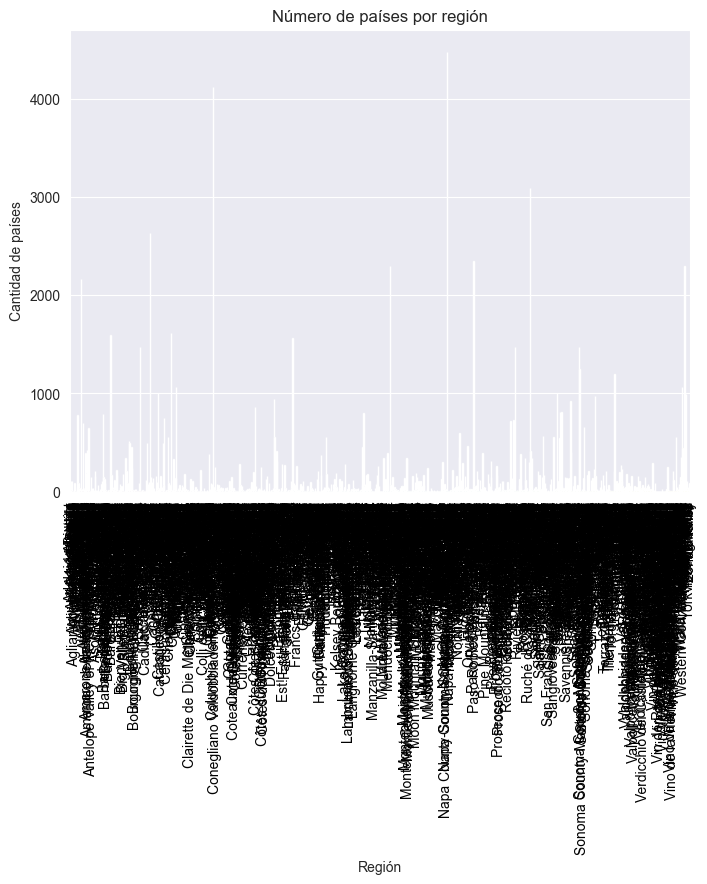

In [37]:
# Agrupar por región y contar los países
conteo_por_region = df.groupby('country')['region_1'].count().reset_index()

# Renombrar columnas para mayor claridad
conteo_por_region.columns = ['Country Count','Region']

# Graficar los resultados usando Seaborn o Matplotlib
plt.figure(figsize=(8, 6))
sns.barplot(x='Country Count', y='Region', data=conteo_por_region, palette='viridis')
plt.title('Número de países por región')
plt.xlabel('Cantidad de países')
plt.ylabel('Región')
plt.xticks(rotation=90,color='black')
plt.show()

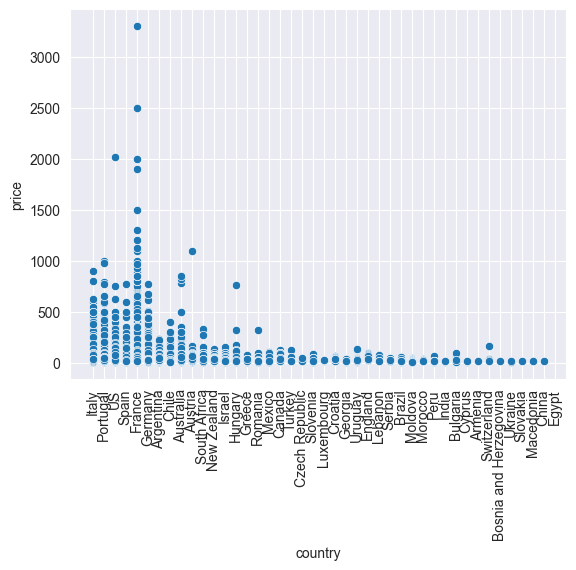

In [16]:
# Aplicar un estilo de Seaborn
sns.set_style("darkgrid")  # Puedes probar también con 'dark', 'whitegrid', etc.
sns.scatterplot(x='country',y='price',data=df,legend='full')
# Rotar las etiquetas del eje x para mostrar los nombres de los países en vertical
plt.xticks(rotation=90)
# Activar la cuadrícula
plt.grid(True)
plt.show()

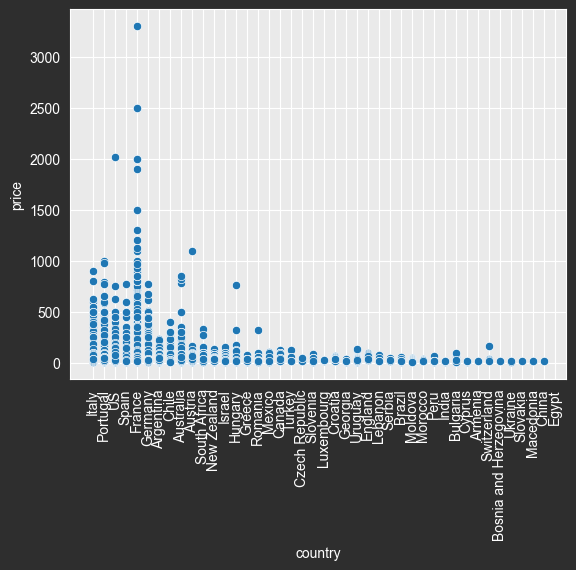

In [21]:
# Crear la figura y el eje
fig, ax = plt.subplots()
# Cambiar el color del fondo de la figura
fig.patch.set_facecolor('#2E2E2E')  # Fondo de la figura (negro/gris oscuro)
# Cambiar el color del fondo del eje
ax.set_facecolor('#EAEAEA')  # Fondo del área de la gráfica (gris claro)

sns.scatterplot(x='country',y='price',data=df,legend='full',ax=ax)
# Rotar las etiquetas del eje x para mostrar los nombres de los países en vertical
ax.tick_params(axis='y', colors='white')

plt.xticks(rotation=90,color='white')
ax.yaxis.label.set_color('white')
ax.xaxis.label.set_color('white')
# Activar la cuadrícula
plt.grid(True)
plt.show()




In [26]:
df.shape

(129971, 14)

Identificación de tipo de variables

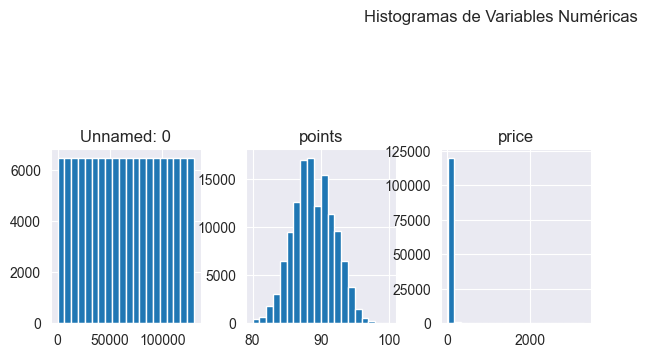

In [27]:
df
df.hist(bins=20, figsize=(12, 14), layout=(5, 5))
plt.suptitle('Histogramas de Variables Numéricas')
plt.show()

Identificación de nulos en variables númericas

In [30]:
# Calcular la cantidad de nulos por columna
nulos_por_columna=df.isnull().sum()

# Calcular el porcentaje de nulos por columna
porcentaje_nulos = (df.isnull().sum() / len(df)) * 100

# Crear un DataFrame con ambas métricas
resumen_nulos = pd.DataFrame({'Nulos': nulos_por_columna, 'Porcentaje Nulos (%)': porcentaje_nulos})

print(resumen_nulos)

                       Nulos  Porcentaje Nulos (%)
Unnamed: 0                 0              0.000000
country                   63              0.048472
description                0              0.000000
designation            37465             28.825661
points                     0              0.000000
price                   8996              6.921544
province                  63              0.048472
region_1               21247             16.347493
region_2               79460             61.136715
taster_name            26244             20.192197
taster_twitter_handle  31213             24.015357
title                      0              0.000000
variety                    1              0.000769
winery                     0              0.000000


Identificación de outlayers

ValueError: The number of FixedLocator locations (5), usually from a call to set_ticks, does not match the number of labels (2).

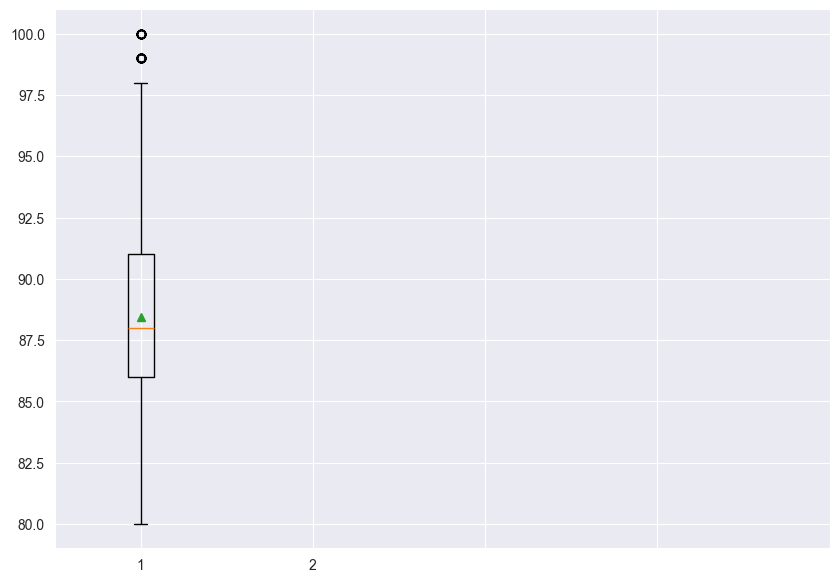

In [28]:
# Crear un gráfico de boxplots para varias columnas
plt.figure(figsize=(10, 7))
# Pasar los datos de las columnas como una lista a plt.boxplot
plt.boxplot([df['points'], df['price']],showmeans=True)
# Configurar los nombres de las etiquetas en el eje x
plt.xticks([1, 2, 3, 4,5], ['points', 'price'])
# Títulos y etiquetas
plt.title("Boxplots de vinos")
plt.ylabel("Accesos (en Millones)")

# Mostrar el gráfico
plt.show()

DataSet con 129 971 observaciones y 14 variables de las cuales 3 son númericas y 11 variables cualitativas